 Customer Churn Analysis with Python

In this project, we analyze customer churn data for a telecom company to understand which customer segments are more likely to churn and why. The insights can help the business improve customer retention by targeting high-risk users.

**Goals of this project:**
- Explore key features contributing to churn
- Visualize patterns across different customer groups
- Share actionable business insights

Step 1: Load the Data

We load the churn dataset and display the first few rows to understand the structure.

In [18]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Show first 5 rows
print(df.head())

# Show dataset info (columns, datatypes, nulls)
print(df.info())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [2]:
# See column names and types
print(df.columns)

# See basic info about each column
print(df.info())

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   obj

Step 2: Data Cleaning

- Converted `TotalCharges` column to numeric
- Removed rows with missing values
- Verified data types and missing value count

In [3]:
# Convert 'TotalCharges' to numbers
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many missing values were created
print(df.isnull().sum())


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [4]:
# Drop rows with missing TotalCharges
df.dropna(inplace=True)

# Confirm again
print(df.isnull().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Step 3: Churn Distribution

We explore the overall churn rate using value counts and percentages.

In [5]:
# Basic churn counts
print(df['Churn'].value_counts())

# Churn percentages
print(df['Churn'].value_counts(normalize=True) * 100)


Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


Insight:
Roughly 26% of customers have churned, which is significant for a subscription-based business.

Step 4: Churn by Contract Type

Customers on month-to-month contracts are far more likely to churn compared to those on one or two-year contracts.

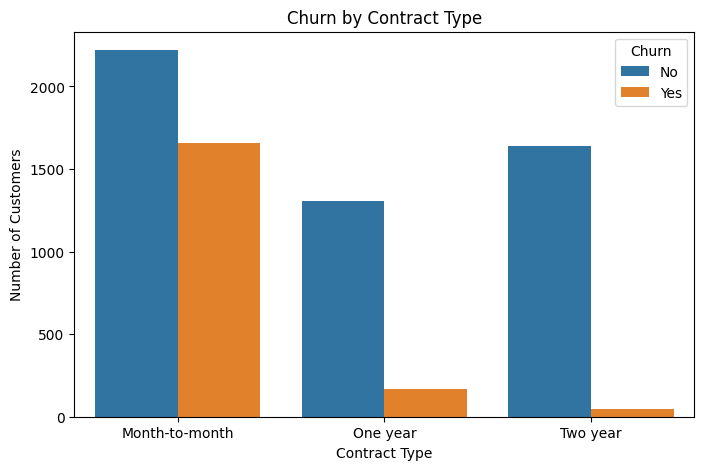

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()


Insight:
Offering better incentives for long-term contracts could reduce churn significantly.

Step 5: Monthly Charges vs Churn

A box plot reveals that customers who churn tend to have higher monthly charges.

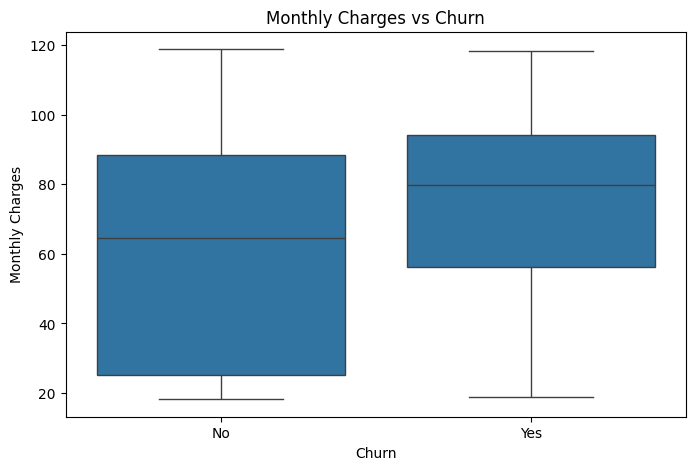

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()


Insight:
High-paying customers might feel underserved or overcharged — a potential churn risk group.

Step 6: Churn by Internet Service Type

We analyze churn behavior across different internet service types (DSL, Fiber optic, No service).

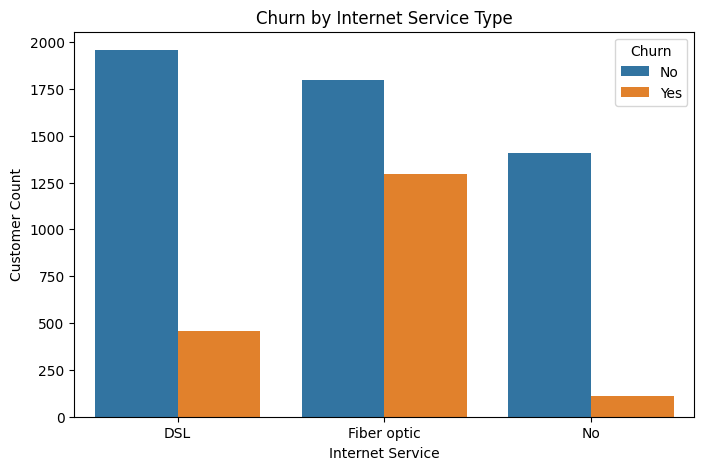

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Customer Count")
plt.show()


Insight:
Fiber optic users churn more often, possibly due to higher costs or inconsistent service quality.

Step 7: Churn by Tenure

A histogram shows that customers who leave often do so within the first few months of joining.

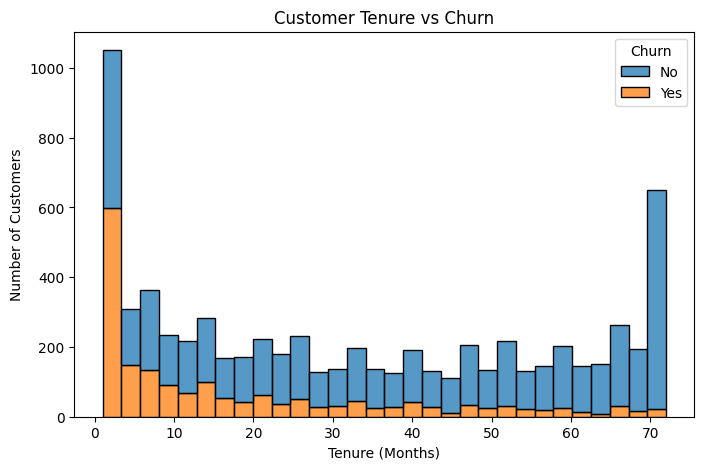

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title("Customer Tenure vs Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()


Insight:
Customer retention efforts should focus on users in their first 6 months.

## Key Business Takeaways

-  Customers with high monthly charges are more likely to churn.
-  Most churn happens in the first 6 months — early engagement is crucial.
-  Month-to-month contracts have much higher churn rates than longer commitments.
-  Fiber optic customers are at greater risk of leaving compared to DSL users.